In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

In [2]:
w = pd.read_csv('ws.csv')

In [3]:
w.id = w.id.str.replace('w', '')
wm = w.melt(id_vars=['Index', 'id', 'group', 'time', 'rank', 'total'], 
            value_vars=w.columns[6:],
            var_name='step',
            value_name='val')

In [4]:
wmf=wm.loc[wm.group=='J'].copy()
wmf['avg'] = wmf['total']/19
wmf[['Index', 'id', 'rank', 'total', 'step', 'val']] = wmf[['Index', 'id', 'rank','total', 'step', 'val']].astype(float)

In [32]:
df = wm.copy()
A = 'step'
B = 'time'
S = 'id'

In [33]:
n = df.groupby(A).ngroups    # levels of factor A, iterated by i
m = df.groupby(B).ngroups    # levels of factor B, iterated by j
l = df.groupby(S).ngroups    # number of subjects, iterated by l
print(n,m,l)

19 2 40


In [34]:
oijk = df.groupby([A,B,S]).val.mean()
# pd multiindex series containing all values

mooo = df.val.mean()
# grand mean

mioo = df.groupby(A).val.mean()
mojo = df.groupby(B).val.mean()
mook = df.groupby(S).val.mean()
# pd series containing means of all levels i of A, j of B, k of S (subjects)

mijo = df.groupby([A,B]).val.mean()
miok = df.groupby([A,S]).val.mean()
mojk = df.groupby([B,S]).val.mean()
# pd multiindex series containing means of all combinations of levels i * j, i * k, j * k

In [35]:
sst = sum((oijk - mooo)**2)
ssa = m * l * sum((mioo - mooo)**2)
ssb = n * l * sum((mojo - mooo)**2)
ssab = l * sum((mijo - mioo - mojo + mooo)**2)
sss = n * m * sum((mook - mooo)**2)
ssas = m * sum((miok - mioo - mook + mooo)**2)
ssbs = n * sum((mojk - mojo - mook + mooo)**2)
ssabs = sum((  oijk
             - mijo - miok - mojk
             + mioo + mojo + mook
             - mooo              )**2)

In [36]:
sse = sum((oijk - mijo)**2)                         # SSError of fully-between two-way ANOVA

sss_B_ = n * sum((mojk - mojo)**2)                  # SSS(B) of partially within two-way ANOVA
sss_B_a = sum((oijk - mijo - mojk + mojo)**2)       # SSS(B)xA of partially within two-way ANOVA

In [56]:
msa = ssa / (n-1)
msb = ssb / (m-1)
msab = ssab / ( (n-1) * (m-1) )

mse = sse / ( m * n * (l-1) )

mss_B_ = sss_B_ / ( m * (l-1) )
mss_B_a = sss_B_a / ( m * (n-1) * (l-1) )

mss = sss / (l-1)
msas = ssas / ( (n-1) * (l-1) )
msbs = ssbs / ( (m-1) * (l-1) )
msabs = ssabs / ( (n-1) * (m-1) * (l-1))

In [57]:
FbA = msa / mse
FbB = msb / mse
FbAB = msab / mse

FmA = msa / mss_B_a
FmB = msb / mss_B_
FmAB = msab / mss_B_a

FwA = msa / msas
FwB = msb / msbs
FwAB = msab / msabs

In [58]:
print(FwA, FwB, FwAB, sep = '\n')

1.8219790495676256
0.6578105503914394
0.9587255405812599


In [55]:
print('SST         ', sst,
      '\nSSE         ', sse,
      '\n\nSSA         ', ssa,
      '\nSSB         ', ssb,
      '\nSSAxB       ', ssab,
      '\n\nSSS         ', sss,
      '\nSSSxA       ', ssas,
      '\nSSSxB       ', ssbs,
      '\nSSSxAxB     ', ssabs,
      '\n\nSSS(B)      ', sss_B_,
      '\nSSS(B)xA    ', sss_B_a, sep='')

SST         70.80649894736842
SSE         68.68227499999999

SSA         1.3607114473684208
SSB         0.12528947368421114
SSAxB       0.6382230263157895

SSS         6.165456842105263
SSSxA       29.126430657894737
SSSxB       7.42811052631579
SSSxAxB     25.96227697368421

SSS(B)      13.593567368421054
SSS(B)xA    55.08870763157894


In [51]:
pd.get_dummies(wm[['val','time','group']], dtype='int')

,val,time_final,time_initial,group_B,group_J
0,0.57,0,1,0,1
1,0.32,0,1,1,0
2,0.56,0,1,0,1
3,0.60,0,1,1,0
4,1.23,0,1,0,1
...,...,...,...,...,...
1515,0.56,1,0,1,0
1516,0.80,1,0,0,1
1517,0.56,1,0,0,1
1518,0.43,1,0,1,0


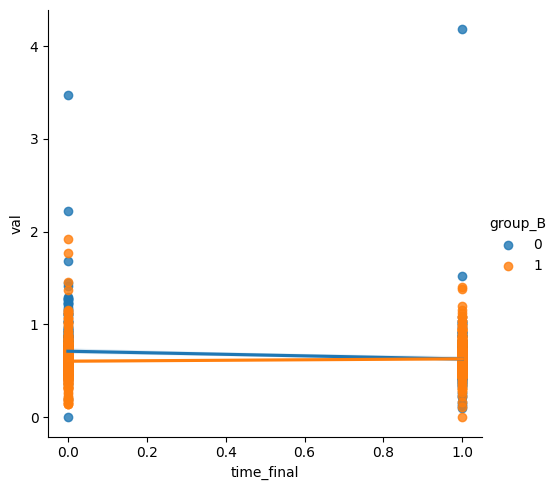

In [56]:
sns.lmplot(pd.get_dummies(wm[['val','time','group']], dtype='int'), x='time_final', y='val', hue='group_B')

In [61]:
smf.ols('val ~ time_final * group_B', pd.get_dummies(wm[['val','time','group']], dtype='int')).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     16.49
Date:                Sun, 31 Aug 2025   Prob (F-statistic):           1.51e-10
Time:                        00:01:15   Log-Likelihood:                 198.17
No. Observations:                1520   AIC:                            -388.3
Df Residuals:                    1516   BIC:                            -367.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7111      0.012     58.300      0.000       0.687       0.735
time_final            -0.0836      0.017     -4.846      0.000      -0.117      -0.050
group_B               -0.1076      0.016     -6.834      0.000      -0.138      -0.077
time_final:group_B     0.1090      0.022      4.897      0.000       0.065       0.153
==============================================================================
Omnibus:                     1740.311   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           346383.150
Skew:                           5.443   Prob(JB):                         0.00
Kurtosis:                      76.148   Cond. No.                         7.66
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""